# Abschlussprojekt 2 – Ereignisanalyse.

Für ein Start-up, das Lebensmittel verkauft, werde ich als Analyst eine Analyse der Ereignisse innerhalb des Verkaufstrichters durchführen, um die Konversion der Nutzer in die nachfolgenden Schritte zu bestimmen und die Ereignisse mit dem größten Nutzerverlust zu identifizieren.

Der zweite große Teil des Projekts besteht in der Durchführung eines A/A/B-Tests mit zwei Kontrollgruppen und einer Testgruppe sowie in der Auswertung der Ergebnisse zur Überprüfung der Hypothese über die Wirksamkeit der vorgenommenen Schriftänderung.

Im Rahmen des Projekts plane ich folgende Schritte:

    1. Sich mit den Daten, ihrem Umfang und ihrem Format vertraut machen.

    2. Eine Datenvorverarbeitung durchführen, indem die Daten auf fehlende Werte sowie auf die für die Analyse erforderlichen Datentypen überprüft werden. Falls erforderlich, fehlende Werte behandeln, die Daten in das passende Format überführen und die Spalten umbenennen.

    3. Im Rahmen der explorativen Datenanalyse folgende Schritte durchführen:

        - die in den Daten enthaltenen Ereignisse untersuchen und die durchschnittliche Anzahl der Ereignisse pro Nutzer berechnen;

        - die zeitlichen Rahmenbedingungen der vorliegenden Daten analysieren, mithilfe einer grafischen Visualisierung deren Vollständigkeit bestimmen und gegebenenfalls unvollständige Daten entfernen, um den tatsächlichen Testzeitraum festzulegen;

        - im Falle der Entfernung unvollständiger Daten deren Anteil am Gesamtdatensatz bewerten, um einen signifikanten Einfluss auf die Testergebnisse auszuschließen.

    4. Event-Funnel analysieren: die Abfolge der Ereignisse im Verkaufstrichter bestimmen, gegebenenfalls optionale Ereignisse aus der Analyse ausschließen, den Anteil der Nutzer auf jeder Stufe berechnen sowie die Verluste identifizieren.

    5. Einen A/A/B-Test durchführen, zunächst die Repräsentativität der Stichproben durch den Vergleich der beiden Kontrollgruppen prüfen und die statistische Signifikanz möglicher Unterschiede bewerten. Anschließend die Ergebnisse der Testgruppe mit denen der Kontrollgruppen vergleichen und gegebenenfalls das Signifikanzniveau für multiple Tests anpassen, um eine fehlerhafte Zurückweisung der Nullhypothese zu vermeiden, und entsprechende Schlussfolgerungen hinsichtlich der möglichen Wirksamkeit der vorgenommenen Änderungen ziehen.

## Erster Blick auf die Daten

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import datetime as dt
import math as mth

In [2]:
sessions = pd.read_csv('/datasets/logs_exp (1).csv', sep = '\t')
display(sessions.head(5))
display(sessions.info())
sessions_shape = sessions.shape[0]

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


None

Basierend auf den vorliegenden Informationen umfasst der Datensatz mehr als 240.000 Ereignisse (Events), die von den Nutzern des Online-Shops generiert wurden. Für jedes Ereignis sind neben der Bezeichnung auch die Nutzer-ID, die Kennung der Experimentalgruppe sowie der Zeitstempel verfügbar.

Auffällig sind die unpräzisen Spaltenbezeichnungen, die den tatsächlichen Inhalt nicht direkt widerspiegeln. Zudem liegt die Zeitangabe im Integer-Format vor; da diese Zahlen nicht unmittelbar lesbar sind, müssen sie in ein für die Analyse geeignetes Datumsformat konvertiert werden. Um den späteren Datenverlust nach der Bereinigung nachvollziehen zu können, wurde die ursprüngliche Anzahl der Datensätze in einer separaten Variable gespeichert.

## Datenaufbereitung und Bereinigung

In [3]:
#Umbenennung der Spalten
sessions.rename(columns={'EventName' : 'event_name', 'DeviceIDHash' : 'user_id', 'EventTimestamp' : 'event_dt', 'ExpId' : 'group_id'}, inplace = True)
display(sessions.columns)

Index(['event_name', 'user_id', 'event_dt', 'group_id'], dtype='object')

In [4]:
#Prüfung auf fehlende Werte und Datentypen
display(sessions.isna().sum())

event_name    0
user_id       0
event_dt      0
group_id      0
dtype: int64

In [5]:
display(sessions.dtypes)

event_name    object
user_id        int64
event_dt       int64
group_id       int64
dtype: object

In [6]:
#изменение типа данных в столбце с датой
sessions['event_dt'] = pd.to_datetime(sessions['event_dt'], unit="s")
display(sessions['event_dt'].dtypes)

dtype('<M8[ns]')

In [7]:
#Datumsspalte hinzufügen
sessions['event_date'] = sessions['event_dt'].dt.date
display(sessions.head(5))

,event_name,user_id,event_dt,group_id,event_date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25


In [8]:
display(sessions[sessions.duplicated()])

,event_name,user_id,event_dt,group_id,event_date
453,MainScreenAppear,5613408041324010552,2019-07-30 08:19:44,248,2019-07-30
2350,CartScreenAppear,1694940645335807244,2019-07-31 21:51:39,248,2019-07-31
3573,MainScreenAppear,434103746454591587,2019-08-01 02:59:37,248,2019-08-01
4076,MainScreenAppear,3761373764179762633,2019-08-01 03:47:46,247,2019-08-01
4803,MainScreenAppear,2835328739789306622,2019-08-01 04:44:01,248,2019-08-01
...,...,...,...,...,...
242329,MainScreenAppear,8870358373313968633,2019-08-07 19:26:44,247,2019-08-07
242332,PaymentScreenSuccessful,4718002964983105693,2019-08-07 19:26:45,247,2019-08-07
242360,PaymentScreenSuccessful,2382591782303281935,2019-08-07 19:27:29,246,2019-08-07
242362,CartScreenAppear,2382591782303281935,2019-08-07 19:27:29,246,2019-08-07


In [9]:
sessions = sessions.drop_duplicates()
display(sessions.duplicated().sum())

0

In [10]:
updated_data_share = sessions.shape[0] / sessions_shape * 100
updated_data_share

99.83082506574475

Der Datensatz enthält 413 Zeilen, die vollständige Duplikate sind. Diese wurden entfernt, da sie für die Analyse redundant sind und nach ihrer Löschung weiterhin mehr als 99 % der Daten erhalten bleiben.

## Explorative Datenanalyse

In [11]:
display(sessions.shape[0])
display(sessions['event_name'].nunique())

243713

5

Es stehen Daten zu fünf eindeutigen Ereignissen zur Verfügung, die insgesamt 243.713 Mal von verschiedenen Nutzern ausgelöst wurden.

In [12]:
display(sessions['user_id'].nunique())

7551

Die Tabelle enthält Daten von 7.551 Nutzern.

In [13]:
user_events = sessions.groupby('user_id').agg({'event_date' : 'count'}).reset_index().rename(columns={'user_id' : 'user_id', 'event_date' : 'events_number'})

display(user_events['events_number'].mean())

32.27559263673685

Im Durchschnitt entfallen auf einen Nutzer etwas mehr als 32 Ereignisse.

In [14]:
display(sessions['event_dt'].min(), sessions['event_dt'].max())

Timestamp('2019-07-25 04:43:36')

Timestamp('2019-08-07 21:15:17')

group_id,event_date,246,247,248
0,2019-07-25,4,1,4
1,2019-07-26,14,8,9
2,2019-07-27,24,23,8
3,2019-07-28,33,36,36
4,2019-07-29,55,58,71
5,2019-07-30,129,138,145
6,2019-07-31,620,664,746
7,2019-08-01,11561,12306,12274
8,2019-08-02,10946,10990,13618
9,2019-08-03,10575,11024,11683


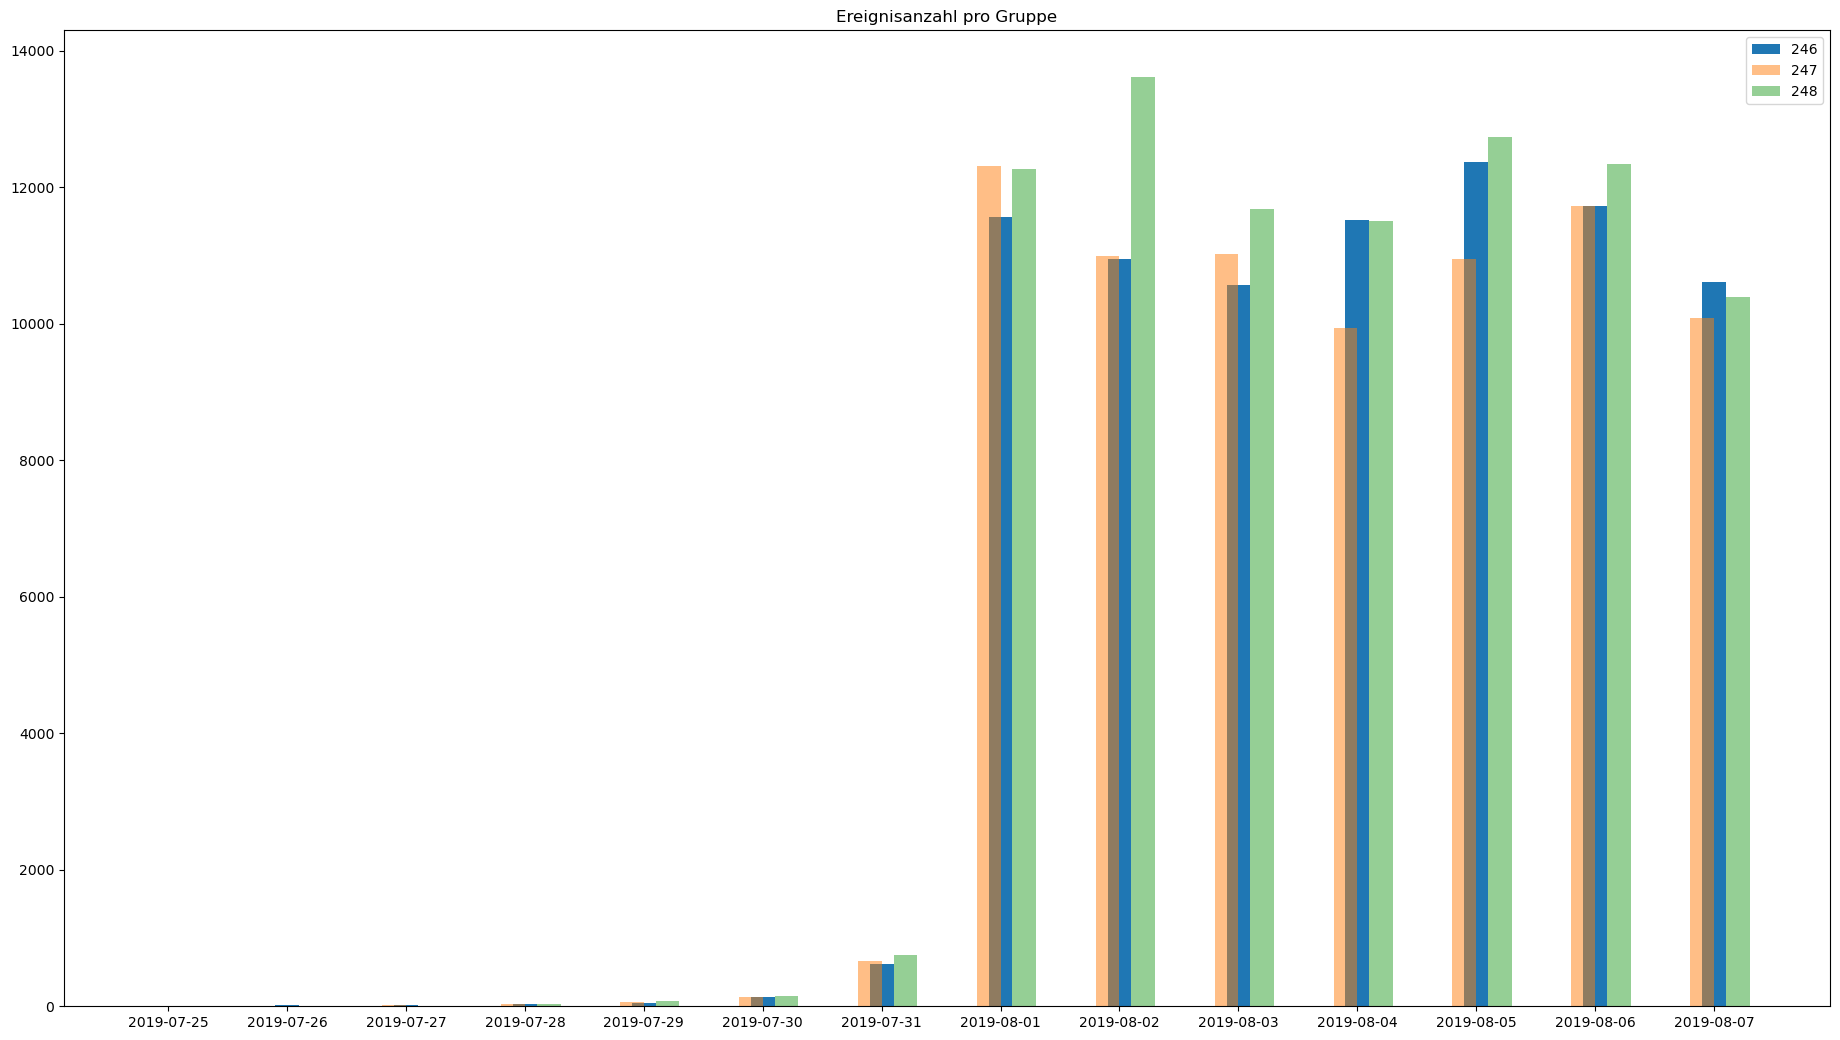

In [15]:
#Balkendiagramm der Anzahl der Ereignisse im Zeitverlauf nach Gruppen
grouped_data = sessions.pivot_table(index = 'event_date', columns = 'group_id', values = 'event_dt', aggfunc = 'count').reset_index()
display(grouped_data)
fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5)
ax.set_title('Ereignisanzahl pro Gruppe')
labels = grouped_data['event_date']
x = np.arange(len(grouped_data['event_date']))
y = grouped_data[246]
y1 = grouped_data[247]
y2 = grouped_data[248]
width = 0.2
plt.bar(x, y, width, label = '246')
plt.bar(x - width/2, y1, width, label = '247', align='center', alpha = 0.5)
plt.bar(x + width/2, y2, width, label = '248', align='edge', alpha = 0.5)
plt.xticks(np.arange(len(grouped_data['event_date'])))
ax.set_xticklabels(labels)
fig.tight_layout()
plt.legend()
plt.show()


In der obigen Grafik ist zu erkennen, dass die Daten vor dem 30.07.2019 nur sehr vereinzelt vorkommen. Es ist zu vermuten, dass diese Daten für einige Nutzer aus der Vergangenheit stammen, was zu einer Verzerrung führt. Für die weitere Analyse ist es sinnvoll, diese Ereignisse auszuschließen, nachdem ihr Anteil an der Gesamtmenge bestimmt wurde.

In [16]:
incomplete_data = sessions.query("event_dt < '2019-08-01'")
display(incomplete_data.shape[0] / sessions.shape[0] * 100)

1.159560630741897

Der Anteil der Sitzungsdaten vor dem 1. August 2019 beträgt etwas mehr als 1 % des Gesamtdatenbestands, was deren Ausschluss aus der Analyse ermöglicht. Somit berücksichtigen wir nur die vollständigen Daten für den Zeitraum vom 01.08.2019 bis zum 07.08.2019, also für genau eine Woche.

In [17]:
sessions_new = sessions.query("event_dt > '2019-08-01'")

display(sessions['user_id'].nunique() - sessions_new['user_id'].nunique(), sessions_new['user_id'].nunique() / sessions['user_id'].nunique() * 100)

17

99.77486425638989

Im neuen Datensatz haben wir Informationen über 17 Nutzer verloren, was ebenfalls akzeptabel ist, da der Anteil der verlorenen Nutzer weniger als 1 % der Gesamtzahl ausmacht.

Nun muss überprüft werden, ob im aktualisierten Datensatz Daten zu allen drei Experimentalgruppen vorhanden sind.

In [18]:
display(sessions_new.groupby('group_id').agg({'event_date' : 'count'}).reset_index())

,group_id,event_date
0,246,79302
1,247,77022
2,248,84563


In der nach den drei Gruppen gruppierten Tabelle ist ersichtlich, dass für jede Gruppe Sitzungsdaten in einer vergleichbaren und für die weitere Analyse geeigneten Menge vorliegen.

## Analyse des Event-Trichters

In [19]:
#Sortierung der Ereignisse nach Häufigkeit
display(sessions_new.groupby('event_name').agg({'event_date' : 'count'}).reset_index().rename(columns={'event_date' : 'events_number'}).sort_values(by = 'events_number', ascending = False))

,event_name,events_number
1,MainScreenAppear,117328
2,OffersScreenAppear,46333
0,CartScreenAppear,42303
3,PaymentScreenSuccessful,33918
4,Tutorial,1005


Wie in der obigen Tabelle ersichtlich ist, enthält der Datensatz fünf verschiedene Ereignisse: MainScreenAppear (Erscheinen des Hauptbildschirms), OffersScreenAppear (Erscheinen der Angebotsseite), CartScreenAppear (Erscheinen des Warenkorbs), PaymentScreenSuccessful (Seite für erfolgreiche Zahlung) und Tutorial (Anleitung). Diese sind nach ihrer Häufigkeit im Datensatz sortiert.

In [20]:
users_by_events = sessions_new.groupby('event_name').agg({'user_id' : 'nunique'}).reset_index().rename(columns={'user_id' : 'users_quantity'}).sort_values(by = 'users_quantity', ascending = False)
users_by_events['users_share'] = round(users_by_events['users_quantity'] / sessions_new['user_id'].nunique() * 100, 2)
display(users_by_events)

,event_name,users_quantity,users_share
1,MainScreenAppear,7419,98.47
2,OffersScreenAppear,4593,60.96
0,CartScreenAppear,3734,49.56
3,PaymentScreenSuccessful,3539,46.97
4,Tutorial,840,11.15


In der obigen Tabelle sehen wir die Anzahl der Nutzer, die jedes der fünf Ereignisse ausgeführt haben, sowie deren prozentualen Anteil an der Gesamtzahl der Nutzer im aktualisierten Datensatz.

Reihenfolge und Kette der Ereignisse

Die Ereignisse finden voraussichtlich in der folgenden Reihenfolge statt: Zuerst sieht der Nutzer den Hauptbildschirm der Website – dann rufen einige die Seite mit der Anleitung/dem Tutorial auf (dieses Ereignis kann auch an einem anderen Punkt auftreten) – danach öffnen die Nutzer die Angebotsseite (auf der Artikel zum Warenkorb hinzugefügt werden können) – wechseln dann zur Warenkorb-Seite, um die Bestellung zu bezahlen – und als letztes Ereignis sieht der Nutzer die Seite für die erfolgreiche Zahlung. Das Ansehen der Anleitung ist eine optionale Aktion, wie aus der Anzahl der ausführenden Nutzer ersichtlich ist, und weist zudem keine feste Position in der Ereigniskette auf. Daher kann dieses Ereignis aus der Trichterberechnung ausgeschlossen werden.

In [21]:
#Berechnung des Anteils der Nutzer, die zum nächsten Schritt übergehen
users_by_events = users_by_events.drop(4)
users_by_events['next_step_quantity'] = users_by_events['users_quantity'].shift()
users_by_events['next_step_share'] = round(users_by_events['users_quantity'] / users_by_events['next_step_quantity'] * 100, 2)
display(users_by_events)

,event_name,users_quantity,users_share,next_step_quantity,next_step_share
1,MainScreenAppear,7419,98.47,NaN,NaN
2,OffersScreenAppear,4593,60.96,7419.0,61.91
0,CartScreenAppear,3734,49.56,4593.0,81.30
3,PaymentScreenSuccessful,3539,46.97,3734.0,94.78


Aus der obigen Tabelle zur Berechnung der Konversionsraten zwischen den Schritten lässt sich schließen, dass der größte Nutzerverlust im ersten Schritt auftritt – beim Übergang von der Hauptseite zur Angebotsseite. Diese Beobachtung bedarf einer weiteren Untersuchung, um die möglichen Ursachen zu identifizieren.

In [22]:
buyers_share = users_by_events.loc[3, 'users_quantity'] / users_by_events.loc[1, 'users_quantity'] * 100
display(buyers_share)

47.70184661005526

Die obigen Berechnungen verdeutlichen, dass etwas weniger als die Hälfte der Nutzer (47,7 %), die die Website besuchen, zu Käufern werden und eine Zahlung erfolgreich abschließen.

## Durchführung und Analyse der A/A/B-Testergebnisse

### A/A-Testing zum Vergleich der beiden Kontrollgruppen

**Nullhypothese H0**: Es gibt keinen Unterschied zwischen den Anteilen der verschiedenen Nutzergruppen.

**Alternativhypothese H1**: Der Unterschied zwischen den Nutzergruppen ist statistisch signifikant.

**Gesamtsignifikanzniveau α** = 0,05

Wir führen einen **Z-Test** durch, um die Anteile der Nutzer in den Gruppen, die die jeweiligen Ereignisse im Verkaufstrichter abgeschlossen haben, im Verhältnis zur Gesamtzahl der Nutzer in der jeweiligen Gruppe zu vergleichen.

In [23]:
display(sessions_new.groupby('group_id').agg({'user_id' : 'nunique'}).reset_index())

,group_id,user_id
0,246,2484
1,247,2513
2,248,2537


Die obige Tabelle zeigt die Anzahl der eindeutigen Nutzer in jeder Experimentalgruppe (etwa 2500 pro Gruppe). Nun muss überprüft werden, ob Nutzer fälschlicherweise in mehr als eine Gruppe gleichzeitig eingeordnet wurden.

In [24]:
display(sessions_new.pivot_table(index='user_id', values='group_id', aggfunc='nunique').sort_values(by = 'group_id', ascending = False))

,group_id
user_id,
6888746892508752,1
6204944347213293942,1
6215559225876063378,1
6215162890135937308,1
6213626876710715478,1
...,...
3171454373076660766,1
3170212200647575044,1
3167974726645136146,1


Indem wir die Anzahl der eindeutigen Gruppen-IDs pro Nutzer berechnet und in absteigender Reihenfolge sortiert haben, lässt sich feststellen, dass jeder Nutzer maximal einer Gruppe zugeordnet ist. Dies bestätigt die Korrektheit des Testdesigns und der Nutzeraufteilung, da keine Überschneidungen zwischen den Gruppen vorliegen.

In [25]:
users246_by_events = sessions_new[sessions_new['group_id'] == 246].groupby('event_name').agg({'user_id' : 'nunique'}).reset_index().rename(columns={'user_id' : 'users_quantity'}).sort_values(by = 'users_quantity', ascending = False)
users246_by_events['total_users'] = sessions_new[sessions_new['group_id'] == 246]['user_id'].nunique()
users246_by_events = users246_by_events.set_index('event_name').drop('Tutorial')
display(users246_by_events)

,users_quantity,total_users
event_name,,
MainScreenAppear,2450,2484
OffersScreenAppear,1542,2484
CartScreenAppear,1266,2484
PaymentScreenSuccessful,1200,2484


In [26]:
users247_by_events = sessions_new[sessions_new['group_id'] == 247].groupby('event_name').agg({'user_id' : 'nunique'}).reset_index().rename(columns={'user_id' : 'users_quantity'}).sort_values(by = 'users_quantity', ascending = False)
users247_by_events['total_users'] = sessions_new[sessions_new['group_id'] == 247]['user_id'].nunique()
users247_by_events = users247_by_events.set_index('event_name').drop('Tutorial')
display(users247_by_events)

,users_quantity,total_users
event_name,,
MainScreenAppear,2476,2513
OffersScreenAppear,1520,2513
CartScreenAppear,1238,2513
PaymentScreenSuccessful,1158,2513


In [27]:
def get_z_results(df1, df2, event_name1):
    alpha = 0.05  # Kritisches Signifikanzniveau
    next_step = np.array([df1.loc[event_name1, 'users_quantity'], df2.loc[event_name1, 'users_quantity']])
    total_users = np.array([df1.loc[event_name1, 'total_users'], df2.loc[event_name1, 'total_users']])

    p1 = next_step[0]/total_users[0]

    p2 = next_step[1]/total_users[1]
    
    p_combined = (next_step[0] + next_step[1]) / (total_users[0] + total_users[1])

    difference = p1 - p2 

    z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/total_users[0] + 1/total_users[1]))
    distr = st.norm(0, 1)  

    p_value = (1 - distr.cdf(abs(z_value))) * 2

    print('p-Wert: ', p_value)

    if p_value < alpha: # ваш код
        print('Die Nullhypothese wird abgelehnt: Es gibt einen statistisch signifikanten Unterschied zwischen den Anteilen der Gruppen.')
    else:
        print(
        'Nicht abgelehnt: Kein signifikanter Unterschied.'
    )

In [28]:
get_z_results(users246_by_events, users247_by_events, event_name1 = 'MainScreenAppear')

p-Wert:  0.7570597232046099
Nicht abgelehnt: Kein signifikanter Unterschied.


In [29]:
get_z_results(users246_by_events, users247_by_events, event_name1 = 'OffersScreenAppear')

p-Wert:  0.2480954578522181
Nicht abgelehnt: Kein signifikanter Unterschied.


In [30]:
get_z_results(users246_by_events, users247_by_events, event_name1 = 'CartScreenAppear')

p-Wert:  0.22883372237997213
Nicht abgelehnt: Kein signifikanter Unterschied.


In [31]:
get_z_results(users246_by_events, users247_by_events, event_name1 = 'PaymentScreenSuccessful')

p-Wert:  0.11456679313141849
Nicht abgelehnt: Kein signifikanter Unterschied.


In [32]:
#Anzahl und Anteil der Nutzer in den Kontrollgruppen
users246_by_events['users_share'] = users246_by_events['users_quantity'] / users246_by_events['total_users'] * 100
users247_by_events['users_share'] = users247_by_events['users_quantity'] / users247_by_events['total_users'] * 100
display(users246_by_events, users247_by_events)

,users_quantity,total_users,users_share
event_name,,,
MainScreenAppear,2450,2484,98.631240
OffersScreenAppear,1542,2484,62.077295
CartScreenAppear,1266,2484,50.966184
PaymentScreenSuccessful,1200,2484,48.309179


,users_quantity,total_users,users_share
event_name,,,
MainScreenAppear,2476,2513,98.527656
OffersScreenAppear,1520,2513,60.485476
CartScreenAppear,1238,2513,49.263828
PaymentScreenSuccessful,1158,2513,46.080382


Die berechneten p-Werte und die daraus gezogenen Schlussfolgerungen zeigen, dass die beiden Kontrollgruppen ähnliche Kennzahlen aufweisen. Das bestätigt eine korrekte Stichprobenbildung.

### A/B-Testing zum Vergleich mit der Testgruppe

**Nullhypothese H0**: Es gibt keinen Unterschied zwischen den Anteilen der verschiedenen Nutzergruppen.

**Alternativhypothese H1**: Der Unterschied zwischen den Nutzergruppen ist statistisch signifikant.

**Gesamtsignifikanzniveau α** = 0,05

**Signifikanzniveau α nach der Šidák-Korrektur** = 0,004

Wir führen ein **Z-Testverfahren** durch, um die Anteile der Nutzer in den Gruppen zu vergleichen, die jedes aufeinanderfolgende Ereignis im Verkaufstrichter abgeschlossen haben, im Verhältnis zur Gesamtzahl der Nutzer in der Gruppe.

In [33]:
#Vergleich mit der Testgruppe
users248_by_events = sessions_new[sessions_new['group_id'] == 248].groupby('event_name').agg({'user_id' : 'nunique'}).reset_index().rename(columns={'user_id' : 'users_quantity'}).sort_values(by = 'users_quantity', ascending = False)
users248_by_events['total_users'] = sessions_new[sessions_new['group_id'] == 248]['user_id'].nunique()
users248_by_events = users248_by_events.set_index('event_name').drop('Tutorial')
users248_by_events['users_share'] = users248_by_events['users_quantity'] / users248_by_events['total_users'] * 100
display(users248_by_events)

,users_quantity,total_users,users_share
event_name,,,
MainScreenAppear,2493,2537,98.265668
OffersScreenAppear,1531,2537,60.346866
CartScreenAppear,1230,2537,48.482460
PaymentScreenSuccessful,1181,2537,46.551045


In [34]:
#Zusammenführung der Kontrollgruppen
users246247_by_events = users246_by_events + users247_by_events
users246247_by_events['users_share'] = users246247_by_events['users_quantity'] / users246247_by_events['total_users'] * 100
display(users246247_by_events)

,users_quantity,total_users,users_share
event_name,,,
MainScreenAppear,4926,4997,98.579147
OffersScreenAppear,3062,4997,61.276766
CartScreenAppear,2504,4997,50.110066
PaymentScreenSuccessful,2358,4997,47.188313


In [35]:
get_z_results(users246_by_events, users248_by_events, event_name1 = 'MainScreenAppear')

p-Wert:  0.2949721933554552
Nicht abgelehnt: Kein signifikanter Unterschied.


In [36]:
get_z_results(users246_by_events, users248_by_events, event_name1 = 'OffersScreenAppear')

p-Wert:  0.20836205402738917
Nicht abgelehnt: Kein signifikanter Unterschied.


In [37]:
get_z_results(users246_by_events, users248_by_events, event_name1 = 'CartScreenAppear')

p-Wert:  0.07842923237520116
Nicht abgelehnt: Kein signifikanter Unterschied.


In [38]:
get_z_results(users246_by_events, users248_by_events, event_name1 = 'PaymentScreenSuccessful')

p-Wert:  0.2122553275697796
Nicht abgelehnt: Kein signifikanter Unterschied.


In [39]:
get_z_results(users247_by_events, users248_by_events, event_name1 = 'MainScreenAppear')

p-Wert:  0.4587053616621515
Nicht abgelehnt: Kein signifikanter Unterschied.


In [40]:
get_z_results(users247_by_events, users248_by_events, event_name1 = 'OffersScreenAppear')

p-Wert:  0.9197817830592261
Nicht abgelehnt: Kein signifikanter Unterschied.


In [41]:
get_z_results(users247_by_events, users248_by_events, event_name1 = 'CartScreenAppear')

p-Wert:  0.5786197879539783
Nicht abgelehnt: Kein signifikanter Unterschied.


In [42]:
get_z_results(users247_by_events, users248_by_events, event_name1 = 'PaymentScreenSuccessful')

p-Wert:  0.7373415053803964
Nicht abgelehnt: Kein signifikanter Unterschied.


In [43]:
get_z_results(users246247_by_events, users248_by_events, event_name1 = 'MainScreenAppear')

p-Wert:  0.29424526837179577
Nicht abgelehnt: Kein signifikanter Unterschied.


In [44]:
get_z_results(users246247_by_events, users248_by_events, event_name1 = 'OffersScreenAppear')

p-Wert:  0.43425549655188256
Nicht abgelehnt: Kein signifikanter Unterschied.


In [45]:
get_z_results(users246247_by_events, users248_by_events, event_name1 = 'CartScreenAppear')

p-Wert:  0.18175875284404386
Nicht abgelehnt: Kein signifikanter Unterschied.


In [46]:
get_z_results(users246247_by_events, users248_by_events, event_name1 = 'PaymentScreenSuccessful')

p-Wert:  0.6004294282308704
Nicht abgelehnt: Kein signifikanter Unterschied.


Keiner der 12 durchgeführten Z-Tests gab Anlass, die Nullhypothese über die Gleichheit der Anteile abzulehnen. Somit ist es hinfällig, über einen Fehler erster Art zu sprechen. Dies deutet darauf hin, dass die Hypothese ineffektiv ist und keine Notwendigkeit besteht, den Test fortzusetzen, da keine statistisch signifikanten Ergebnisse erzielt wurden.

In [47]:
#Anpassung des Signifikanzniveaus für 12 Tests
m = 12
alpha = 0.05
alpha_sidak = 1 - (1 - alpha) ** (1/m)
fwer_sidak = 1 - (1 - alpha_sidak) ** m
alpha_sidak, fwer_sidak

(0.004265318777560645, 0.04999999999999971)

Bei der Durchführung multipler Tests am selben Datensatz erhöht sich in der Regel die Wahrscheinlichkeit eines Fehlers erster Art (das fälschliche Ablehnen einer korrekten Nullhypothese).

Durch die Senkung des Signifikanzniveaus für den Einzeltest mittels der Šidák-Methode (auf 0,004) reduzieren wir dieses Risiko und halten das kumulierte Signifikanzniveau aller Tests auf dem gewünschten Gesamtniveau (strebend gegen 0,05). In diesem speziellen Fall änderte die Anpassung des Alpha-Werts an keinem der Testergebnisse etwas, da ohnehin keine Nullhypothese abgelehnt wurde.

## Abschließendes Fazit

Вот перевод вашего итогового вывода на немецкий язык с сохранением структуры Markdown:

Alle ursprünglich geplanten Etappen der Projektarbeit wurden abgeschlossen.

    1. Es gibt keine fehlenden Werte; der Datentyp in der Datumsspalte wurde in das erforderliche Format konvertiert.
    2. Die durchschnittliche Anzahl der Ereignisse pro Nutzer wurde ermittelt (etwas mehr als 32), ebenso wie das Mindest- und Höchstdatum der in der Tabelle vorhandenen Ereignisse.
    3. Weniger als 2 % der Ereignisse aus dem Gesamtdatensatz, die von weniger als 1 % der Nutzer durchgeführt wurden, wurden entfernt, um den Datensatz von unvollständigen Daten zu bereinigen. Somit liegen für die Analyse Daten über den Testzeitraum von einer Woche vom 01. bis zum 07. August 2019 vor.
    4. Bei der Untersuchung des Verkaufstrichters wurden fünf Ereignisse im Datensatz sowie deren Reihenfolge festgelegt. Das Ereignis „Tutorial“ wurde aus der Analyse ausgeschlossen, da es nicht Teil des sequenziellen Kaufprozesses auf der Website ist, optional bleibt und nur von einem geringen Prozentsatz der Nutzer durchgeführt wird.
    5. Die Konversionsraten der Nutzer für jeden Folgeschritt wurden berechnet. Beim ersten Übergang vom ersten zum zweiten Ereignis geht die größte Anzahl an Website-Besuchern verloren.
    6. Nach Durchführung des A/A-Tests zum Vergleich der beiden Kontrollgruppen 246 und 247 wurde die Korrektheit der Stichproben im Datensatz bestätigt; Hypothesen über statistisch signifikante Unterschiede zwischen ihnen wurden abgelehnt.
    7. Die Berechnung der A/B-Testergebnisse zum Vergleich der Kontrollgruppen mit der Testgruppe 248 zeigte ebenfalls keine statistisch signifikanten Resultate. Es gibt keine Grundlage, eine der Nullhypothesen über die Gleichheit der Gruppen abzulehnen.

Somit kann das Testing beendet und die Hypothese über den Einfluss der Schriftänderung auf die Steigerung der Nutzerzahlen als ineffektiv eingestuft werden.